In [1]:
!pip install requests pandas tqdm

In [2]:
import requests
import pandas as pd
from tqdm import tqdm

In [5]:
BASE_URL = "https://huggingface.co/api/models"

 

In [6]:
res = requests.get(BASE_URL)
res

<Response [200]>

In [7]:
TARGET_ROWS = 5000
LIMIT_PER_REQUEST = 500 

In [8]:
def fetch_models(offset=0):
    
    params = {
        "limit": LIMIT_PER_REQUEST,
        "sort": "downloads",
        "direction": -1,
        "offset": offset
    }

    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()

    return response.json()

In [9]:
all_models = []
cursor = None

while len(all_models) < TARGET_ROWS:
    
    data = fetch_models(cursor)

    if not data:
        break

    all_models.extend(data)

    # pagination cursor
    cursor = data[-1]["id"]

    print(f"Collected: {len(all_models)} models")

Collected: 500 models
Collected: 1000 models
Collected: 1500 models
Collected: 2000 models
Collected: 2500 models
Collected: 3000 models
Collected: 3500 models
Collected: 4000 models
Collected: 4500 models
Collected: 5000 models


In [11]:
clean_data = []

for model in tqdm(all_models[:TARGET_ROWS]):

    model_id = model.get("id", "")
    
    # model name = last part of id
    model_name = model_id.split("/")[-1] if model_id else ""

    author = model.get("author", "")
    task_type = model.get("pipeline_tag", "")
    downloads = model.get("downloads", 0)
    likes = model.get("likes", 0)
    created_at = model.get("createdAt", "")

    # library extraction from tags
    tags = model.get("tags", [])
    library = ""

    for tag in tags:
        if tag.startswith("library:"):
            library = tag.replace("library:", "")
            break

    clean_data.append({
        "model_id": model_id,
        "model_name": model_name,
        "author": author,
        "task_type": task_type,
        "downloads": downloads,
        "likes": likes,
        "library": library,
        "created_at": created_at
    })

100%|██████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 312858.34it/s]


In [12]:
df = pd.DataFrame(clean_data)

df

,model_id,model_name,author,task_type,downloads,likes,library,created_at
0,sentence-transformers/all-MiniLM-L6-v2,all-MiniLM-L6-v2,,sentence-similarity,194794489,4666,,2022-03-02T23:29:05.000Z
1,google-bert/bert-base-uncased,bert-base-uncased,,fill-mask,67627896,2616,,2022-03-02T23:29:04.000Z
2,google/electra-base-discriminator,electra-base-discriminator,,,48676934,90,,2022-03-02T23:29:05.000Z
3,Falconsai/nsfw_image_detection,nsfw_image_detection,,image-classification,38057004,1039,,2023-10-13T23:50:01.000Z
4,sentence-transformers/all-mpnet-base-v2,all-mpnet-base-v2,,sentence-similarity,29342528,1274,,2022-03-02T23:29:05.000Z
...,...,...,...,...,...,...,...,...
4995,microsoft/phi-4,phi-4,,text-generation,638810,2224,,2024-12-11T11:47:29.000Z
4996,Helsinki-NLP/opus-mt-nl-en,opus-mt-nl-en,,translation,638106,9,,2022-03-02T23:29:04.000Z
4997,farbodtavakkoli/OTel-LLM-0.6B-IT,OTel-LLM-0.6B-IT,,text-generation,637699,0,,2026-02-11T07:42:01.000Z
4998,farbodtavakkoli/OTel-Embedding-109M,OTel-Embedding-109M,,feature-extraction,635436,0,,2026-02-02T10:27:57.000Z


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_id    5000 non-null   object
 1   model_name  5000 non-null   object
 2   author      5000 non-null   object
 3   task_type   5000 non-null   object
 4   downloads   5000 non-null   int64 
 5   likes       5000 non-null   int64 
 6   library     5000 non-null   object
 7   created_at  5000 non-null   object
dtypes: int64(2), object(6)
memory usage: 312.6+ KB


In [14]:
df["author"] = df["model_id"].apply(
    lambda x: x.split("/")[0] if "/" in str(x) else "unknown"
)

In [15]:
df['author'].head()

0    sentence-transformers
1              google-bert
2                   google
3                Falconsai
4    sentence-transformers
Name: author, dtype: object

In [16]:
all_models[0].keys()

dict_keys(['_id', 'id', 'likes', 'private', 'downloads', 'tags', 'pipeline_tag', 'library_name', 'createdAt', 'modelId'])

In [17]:
df['task_type'].unique()

array(['sentence-similarity', 'fill-mask', '', 'image-classification',
       'zero-shot-image-classification', 'audio-classification',
       'text-ranking', 'feature-extraction', 'text-generation',
       'time-series-forecasting', 'voice-activity-detection',
       'automatic-speech-recognition', 'text-to-speech',
       'image-text-to-text', 'text-classification',
       'image-feature-extraction', 'image-to-text', 'keypoint-detection',
       'any-to-any', 'zero-shot-classification', 'object-detection',
       'image-to-3d', 'depth-estimation', 'token-classification',
       'mask-generation', 'summarization', 'text-to-image', 'translation',
       'zero-shot-object-detection', 'image-to-video', 'image-to-image',
       'audio-to-audio', 'text-to-audio', 'robotics',
       'tabular-classification', 'image-segmentation',
       'table-question-answering', 'question-answering',
       'audio-text-to-text', 'video-classification'], dtype=object)

In [18]:
(df["task_type"] == "").sum()

np.int64(540)

In [19]:
empty_percent = (df["task_type"] == "").mean() * 100
print(f"Percentage empty: {empty_percent:.2f}%")

Percentage empty: 10.80%


In [20]:
df["task_type"] = df["task_type"].replace("", "unknown")

In [21]:
df['task_type'].unique()

array(['sentence-similarity', 'fill-mask', 'unknown',
       'image-classification', 'zero-shot-image-classification',
       'audio-classification', 'text-ranking', 'feature-extraction',
       'text-generation', 'time-series-forecasting',
       'voice-activity-detection', 'automatic-speech-recognition',
       'text-to-speech', 'image-text-to-text', 'text-classification',
       'image-feature-extraction', 'image-to-text', 'keypoint-detection',
       'any-to-any', 'zero-shot-classification', 'object-detection',
       'image-to-3d', 'depth-estimation', 'token-classification',
       'mask-generation', 'summarization', 'text-to-image', 'translation',
       'zero-shot-object-detection', 'image-to-video', 'image-to-image',
       'audio-to-audio', 'text-to-audio', 'robotics',
       'tabular-classification', 'image-segmentation',
       'table-question-answering', 'question-answering',
       'audio-text-to-text', 'video-classification'], dtype=object)

In [22]:
(df["task_type"] == "").sum()

np.int64(0)

In [23]:
(df["task_type"] == "unknown").sum()

np.int64(540)

In [24]:
df

,model_id,model_name,author,task_type,downloads,likes,library,created_at
0,sentence-transformers/all-MiniLM-L6-v2,all-MiniLM-L6-v2,sentence-transformers,sentence-similarity,194794489,4666,,2022-03-02T23:29:05.000Z
1,google-bert/bert-base-uncased,bert-base-uncased,google-bert,fill-mask,67627896,2616,,2022-03-02T23:29:04.000Z
2,google/electra-base-discriminator,electra-base-discriminator,google,unknown,48676934,90,,2022-03-02T23:29:05.000Z
3,Falconsai/nsfw_image_detection,nsfw_image_detection,Falconsai,image-classification,38057004,1039,,2023-10-13T23:50:01.000Z
4,sentence-transformers/all-mpnet-base-v2,all-mpnet-base-v2,sentence-transformers,sentence-similarity,29342528,1274,,2022-03-02T23:29:05.000Z
...,...,...,...,...,...,...,...,...
4995,microsoft/phi-4,phi-4,microsoft,text-generation,638810,2224,,2024-12-11T11:47:29.000Z
4996,Helsinki-NLP/opus-mt-nl-en,opus-mt-nl-en,Helsinki-NLP,translation,638106,9,,2022-03-02T23:29:04.000Z
4997,farbodtavakkoli/OTel-LLM-0.6B-IT,OTel-LLM-0.6B-IT,farbodtavakkoli,text-generation,637699,0,,2026-02-11T07:42:01.000Z
4998,farbodtavakkoli/OTel-Embedding-109M,OTel-Embedding-109M,farbodtavakkoli,feature-extraction,635436,0,,2026-02-02T10:27:57.000Z


In [25]:
df["library"].value_counts().head(20)

library
    5000
Name: count, dtype: int64

In [26]:
print(all_models[0])

{'_id': '621ffdc136468d709f180294', 'id': 'sentence-transformers/all-MiniLM-L6-v2', 'likes': 4666, 'private': False, 'downloads': 194794489, 'tags': ['sentence-transformers', 'pytorch', 'tf', 'rust', 'onnx', 'safetensors', 'openvino', 'bert', 'feature-extraction', 'sentence-similarity', 'transformers', 'en', 'dataset:s2orc', 'dataset:flax-sentence-embeddings/stackexchange_xml', 'dataset:ms_marco', 'dataset:gooaq', 'dataset:yahoo_answers_topics', 'dataset:code_search_net', 'dataset:search_qa', 'dataset:eli5', 'dataset:snli', 'dataset:multi_nli', 'dataset:wikihow', 'dataset:natural_questions', 'dataset:trivia_qa', 'dataset:embedding-data/sentence-compression', 'dataset:embedding-data/flickr30k-captions', 'dataset:embedding-data/altlex', 'dataset:embedding-data/simple-wiki', 'dataset:embedding-data/QQP', 'dataset:embedding-data/SPECTER', 'dataset:embedding-data/PAQ_pairs', 'dataset:embedding-data/WikiAnswers', 'arxiv:1904.06472', 'arxiv:2102.07033', 'arxiv:2104.08727', 'arxiv:1704.05179',

In [27]:
library_map = {
    model["id"]: model.get("library_name", "unknown")
    for model in all_models
}

In [28]:
df["library"] = df["model_id"].map(library_map)

In [29]:
df["library"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: library
Non-Null Count  Dtype 
--------------  ----- 
5000 non-null   object
dtypes: object(1)
memory usage: 39.2+ KB


In [30]:
df["library"].unique()

array(['sentence-transformers', 'transformers', 'ultralytics', 'timm',
       'chronos-forecasting', 'pyannote-audio', 'unknown',
       'diffusion-single-file', 'UniDepth', 'coqui', 'whisperkit',
       'open_clip', 'mivolo', 'trellis', 'vllm', 'diffusers', 'model2vec',
       'transformers.js', 'speechbrain', 'chatterbox', 'PyTorch',
       'ctranslate2', 'mlx', 'granite-tsfm', 'nemo', 'Model Optimizer',
       'peft', 'f5-tts', 'birefnet'], dtype=object)

In [31]:
(df['library']=='unknown').sum()

np.int64(440)

In [33]:
'' in df['author'] or ' ' in df['author']

False

In [39]:
df.head(50)

,model_id,model_name,author,task_type,downloads,likes,library,created_at
0,sentence-transformers/all-MiniLM-L6-v2,all-MiniLM-L6-v2,sentence-transformers,sentence-similarity,194794489,4666,sentence-transformers,2022-03-02T23:29:05.000Z
1,google-bert/bert-base-uncased,bert-base-uncased,google-bert,fill-mask,67627896,2616,transformers,2022-03-02T23:29:04.000Z
2,google/electra-base-discriminator,electra-base-discriminator,google,unknown,48676934,90,transformers,2022-03-02T23:29:05.000Z
3,Falconsai/nsfw_image_detection,nsfw_image_detection,Falconsai,image-classification,38057004,1039,transformers,2023-10-13T23:50:01.000Z
4,sentence-transformers/all-mpnet-base-v2,all-mpnet-base-v2,sentence-transformers,sentence-similarity,29342528,1274,sentence-transformers,2022-03-02T23:29:05.000Z
5,openai/clip-vit-large-patch14,clip-vit-large-patch14,openai,zero-shot-image-classification,29169880,1986,transformers,2022-03-02T23:29:05.000Z
6,sentence-transformers/paraphrase-multilingual-...,paraphrase-multilingual-MiniLM-L12-v2,sentence-transformers,sentence-similarity,28552443,1191,sentence-transformers,2022-03-02T23:29:05.000Z
7,openai/clip-vit-base-patch32,clip-vit-base-patch32,openai,zero-shot-image-classification,20690471,903,transformers,2022-03-02T23:29:05.000Z
8,FacebookAI/roberta-large,roberta-large,FacebookAI,fill-mask,20200655,273,transformers,2022-03-02T23:29:04.000Z
9,laion/clap-htsat-fused,clap-htsat-fused,laion,audio-classification,19699862,74,transformers,2023-02-16T20:45:11.000Z


In [36]:
(df['downloads']==0).sum()

np.int64(0)

In [37]:
df["task_type"].value_counts().head(10)

task_type
text-generation                 1130
unknown                          540
image-text-to-text               490
sentence-similarity              390
automatic-speech-recognition     360
feature-extraction               340
fill-mask                        260
text-classification              170
image-classification             160
time-series-forecasting          150
Name: count, dtype: int64

In [40]:
df.rename(columns={"author": "owner"}, inplace=True)

In [42]:
df.to_csv('E:\DataSets\huggingface_models.csv',index = False)

# 📊 Exploratory Data Analysis of Hugging Face Models

This project performs Exploratory Data Analysis (EDA) on AI models hosted on Hugging Face.

### Objectives:
- Understand model popularity trends
- Analyze dominant AI task categories
- Study library ecosystem
- Examine relationships between downloads and likes
- Analyze growth of models over time

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 📐 Dataset Overview

In [43]:
print("Shape:", df.shape)
df.head()

Shape: (5000, 8)


,model_id,model_name,owner,task_type,downloads,likes,library,created_at
0,sentence-transformers/all-MiniLM-L6-v2,all-MiniLM-L6-v2,sentence-transformers,sentence-similarity,194794489,4666,sentence-transformers,2022-03-02T23:29:05.000Z
1,google-bert/bert-base-uncased,bert-base-uncased,google-bert,fill-mask,67627896,2616,transformers,2022-03-02T23:29:04.000Z
2,google/electra-base-discriminator,electra-base-discriminator,google,unknown,48676934,90,transformers,2022-03-02T23:29:05.000Z
3,Falconsai/nsfw_image_detection,nsfw_image_detection,Falconsai,image-classification,38057004,1039,transformers,2023-10-13T23:50:01.000Z
4,sentence-transformers/all-mpnet-base-v2,all-mpnet-base-v2,sentence-transformers,sentence-similarity,29342528,1274,sentence-transformers,2022-03-02T23:29:05.000Z


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_id    5000 non-null   object
 1   model_name  5000 non-null   object
 2   owner       5000 non-null   object
 3   task_type   5000 non-null   object
 4   downloads   5000 non-null   int64 
 5   likes       5000 non-null   int64 
 6   library     5000 non-null   object
 7   created_at  5000 non-null   object
dtypes: int64(2), object(6)
memory usage: 312.6+ KB


In [46]:
df.describe()

,downloads,likes
count,5.000000e+03,5000.000000
mean,3.334415e+06,609.150000
std,1.015022e+07,1241.720151
min,6.337610e+05,0.000000
25%,8.423682e+05,49.000000
50%,1.263238e+06,197.000000
75%,2.582342e+06,668.000000
max,1.947945e+08,13156.000000


## 🔍 Checking Unique Values

In [48]:
df.nunique()

model_id      500
model_name    492
owner         182
task_type      40
downloads     500
likes         352
library        29
created_at    393
dtype: int64

## 📊 Statistical Summary

In [49]:
df[["downloads", "likes"]].describe()

,downloads,likes
count,5.000000e+03,5000.000000
mean,3.334415e+06,609.150000
std,1.015022e+07,1241.720151
min,6.337610e+05,0.000000
25%,8.423682e+05,49.000000
50%,1.263238e+06,197.000000
75%,2.582342e+06,668.000000
max,1.947945e+08,13156.000000


## 📊 Univariate Analysis

Univariate analysis focuses on analyzing individual variables to understand their distribution, spread, and characteristics.

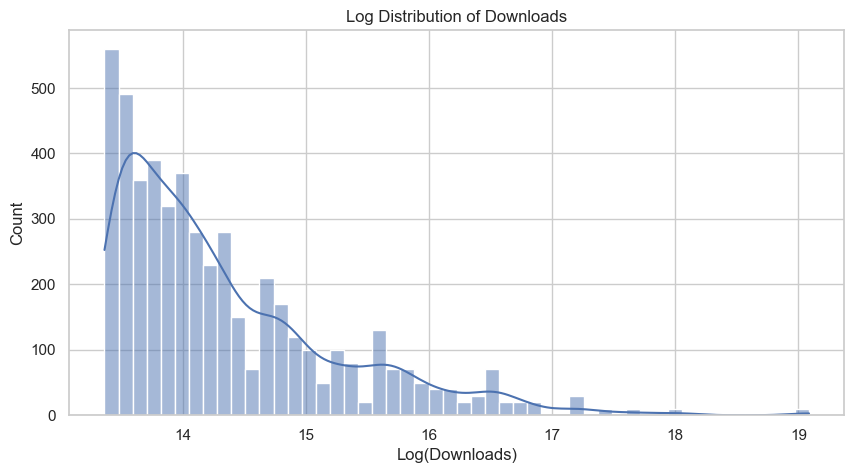

In [54]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df["downloads"]), bins=50,kde = True)
plt.title("Log Distribution of Downloads")
plt.xlabel("Log(Downloads)")
plt.show()

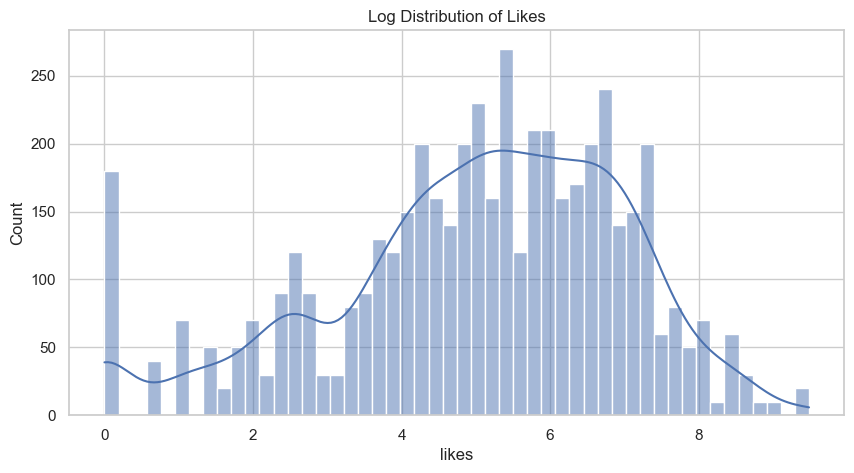

In [52]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df["likes"]), bins=50,kde = True)
plt.title("Log Distribution of Likes")
plt.show()

In [68]:
df["task_type"].value_counts().head(10)

task_type
text-generation                 1130
unknown                          540
image-text-to-text               490
sentence-similarity              390
automatic-speech-recognition     360
feature-extraction               340
fill-mask                        260
text-classification              170
image-classification             160
time-series-forecasting          150
Name: count, dtype: int64

### 🧠 Insights:
- Downloads and likes are highly skewed
- Few models dominate popularity
- Most models have low engagement`

## 🔗 Bivariate Analysis

Examines relationships between two variables.

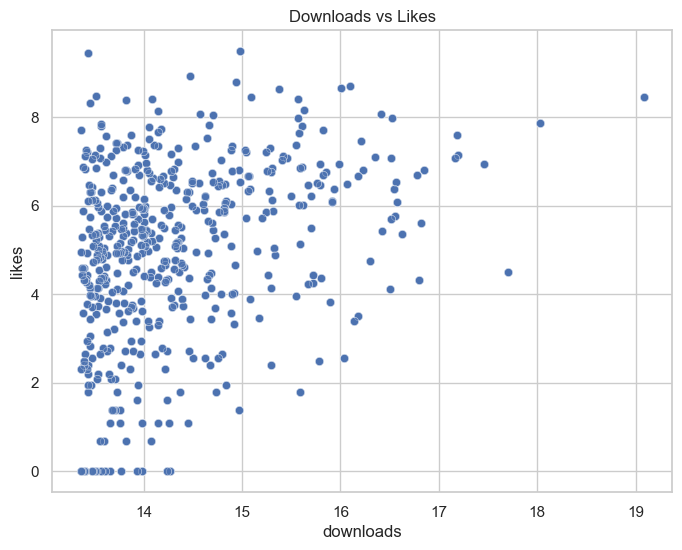

In [69]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=np.log1p(df["downloads"]),
    y=np.log1p(df["likes"]),
    alpha=0.5
)
plt.title("Downloads vs Likes")
plt.show()

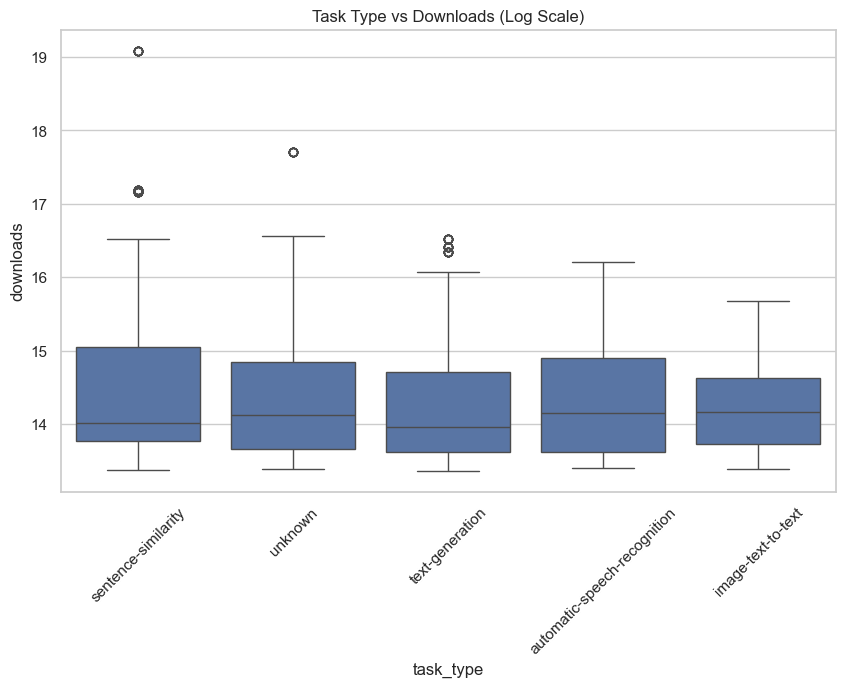

In [71]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=filtered,
    x="task_type",
    y=np.log1p(filtered["downloads"])
)

plt.xticks(rotation=45)
plt.title("Task Type vs Downloads (Log Scale)")
plt.show()

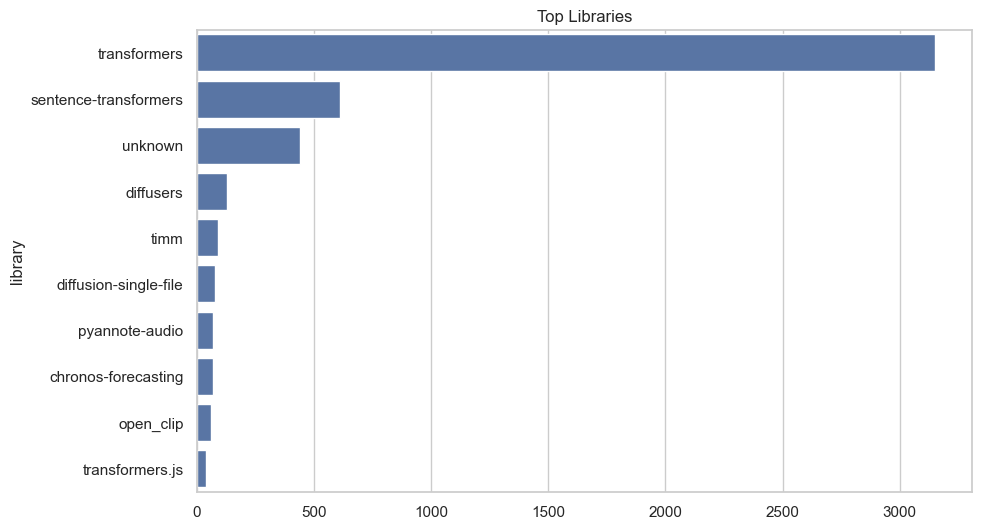

In [72]:
top_libs = df["library"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_libs.values, y=top_libs.index)
plt.title("Top Libraries")
plt.show()

## 📅 Time Trend Analysis

C:\Users\mmkya\AppData\Local\Temp\ipykernel_14812\3905135364.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df["created_at"].dt.to_period("M")).size()


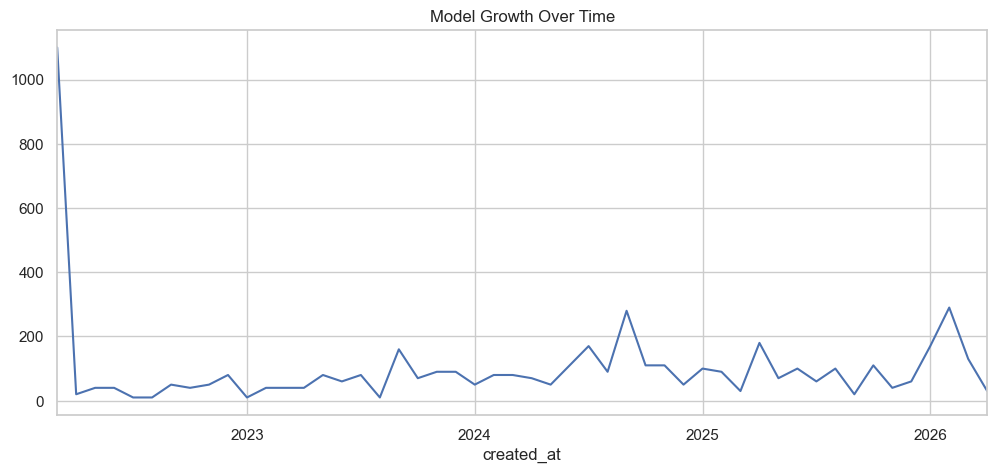

In [73]:
df["created_at"] = pd.to_datetime(df["created_at"])

monthly = df.groupby(df["created_at"].dt.to_period("M")).size()

monthly.plot(figsize=(12,5))
plt.title("Model Growth Over Time")
plt.show()

## 📌 Conclusion

- Model popularity is highly skewed
- NLP dominates AI tasks
- Transformers ecosystem leads development
- Strong correlation between downloads and likes
- AI model growth is increasing rapidly
- Libraries are task-specific in many cases

## 🔍 Multivariate Analysis

Multivariate analysis examines relationships between more than two variables simultaneously.

This helps uncover patterns involving:
- Downloads
- Likes
- Task types
- Libraries

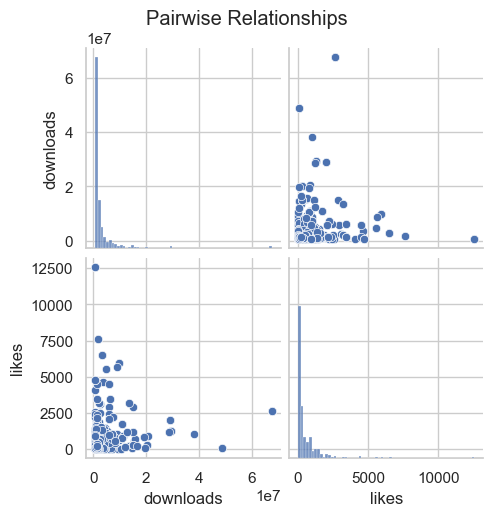

In [75]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(sample_df[["downloads","likes"]])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

### 🧠 Insight:
- Strong positive relationship between downloads and likes
- Confirms popularity consistency across metrics

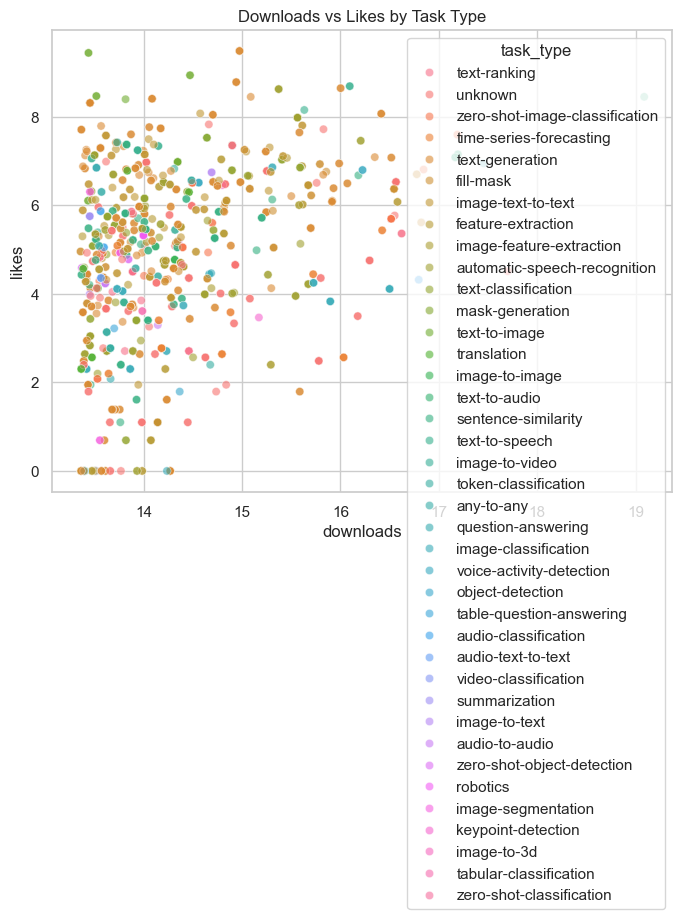

In [76]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(1000),
    x=np.log1p(df["downloads"]),
    y=np.log1p(df["likes"]),
    hue="task_type",
    alpha=0.6
)

plt.title("Downloads vs Likes by Task Type")
plt.show()

### 🧠 Insight:
- Different task types cluster differently
- Some tasks dominate high-download regions

## 🔥 Heatmap Analysis

Heatmaps help visualize relationships and distributions across multiple variables.

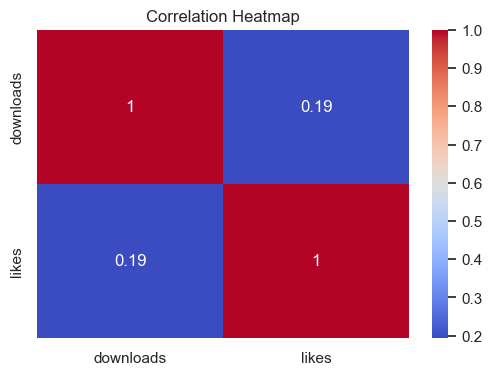

In [78]:
corr = df[["downloads","likes"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

### 🧠 Insight:
- Strong positive correlation between downloads and likes

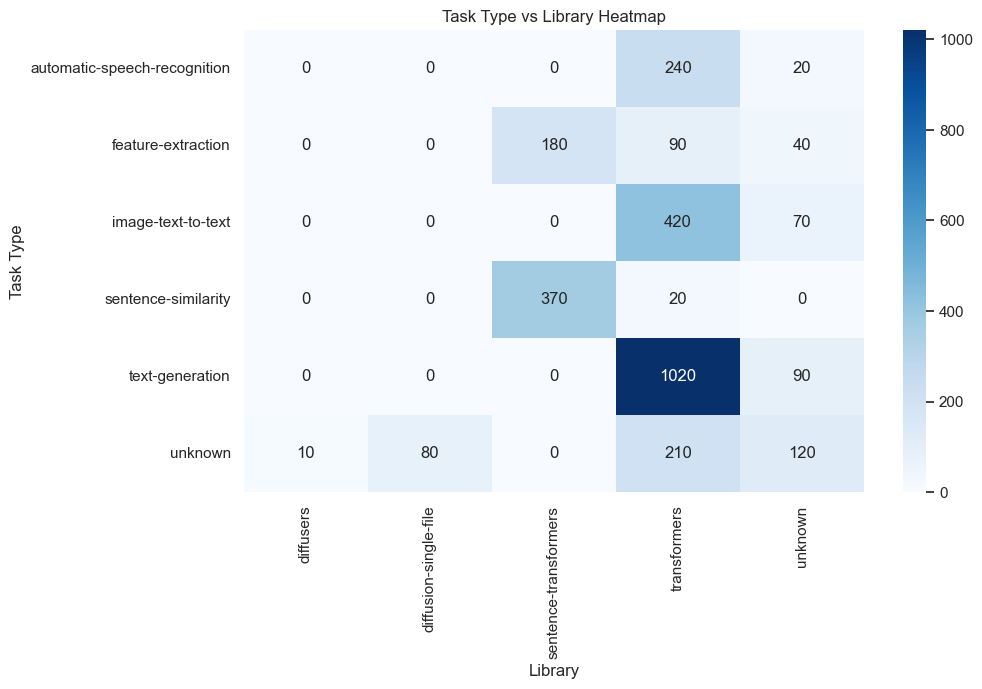

In [79]:
top_tasks = df["task_type"].value_counts().head(6).index
top_libs = df["library"].value_counts().head(6).index

filtered = df[
    (df["task_type"].isin(top_tasks)) &
    (df["library"].isin(top_libs))
]

pivot = pd.crosstab(filtered["task_type"], filtered["library"])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")

plt.title("Task Type vs Library Heatmap")
plt.xlabel("Library")
plt.ylabel("Task Type")
plt.show()

### 🧠 Insight:
- Certain libraries dominate specific task types
- Shows specialization of frameworks

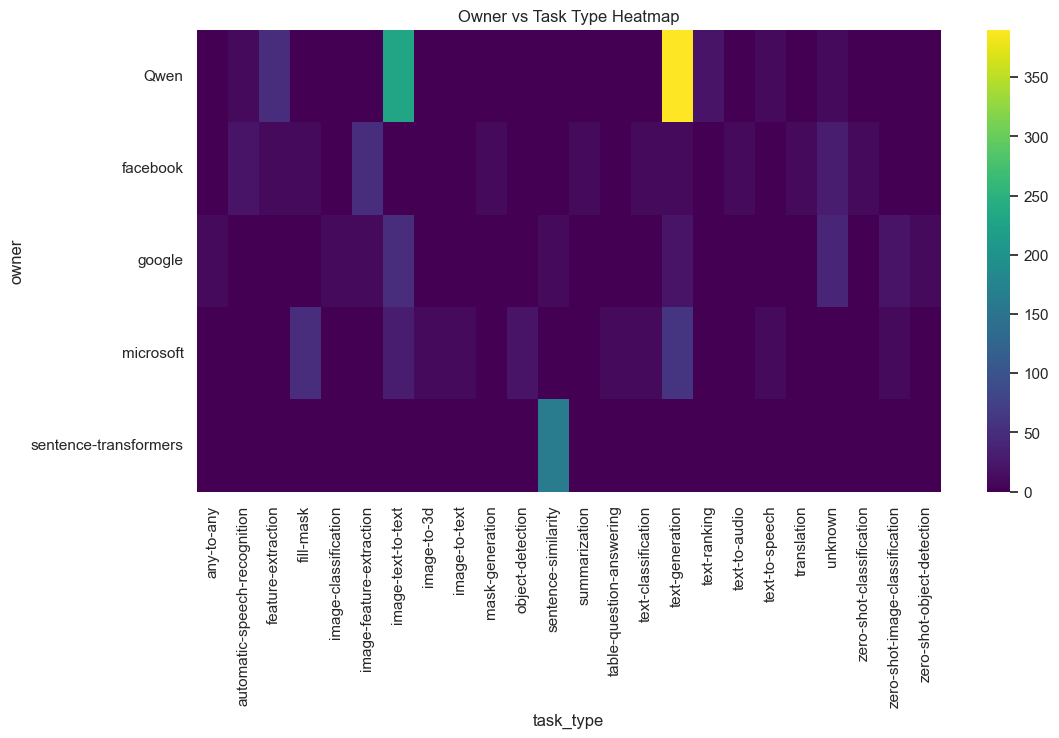

In [80]:
top_owners = df["owner"].value_counts().head(5).index

filtered = df[df["owner"].isin(top_owners)]

pivot = pd.crosstab(filtered["owner"], filtered["task_type"])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="viridis")

plt.title("Owner vs Task Type Heatmap")
plt.show()

### 🧠 Insight:
- Some organizations focus on specific AI domains
- Shows specialization patterns

## 📌 Multivariate Insights

- Downloads and likes show strong correlation
- Task types influence model popularity
- Libraries are specialized for certain tasks
- Some organizations dominate specific domains